# 07 — Model Comparison, Second Generation

`06_model_comparison.ipynb` tested a structural prior — "tabular data
favors tree ensembles" — and that prior lost. Ridge beat all four
tree-based models on RMSE. That result was flagged rather than waved
through: `distance` alone carries a 0.91 raw correlation with
`posted_rate` (from `03_eda.ipynb`), close enough to a dominant linear
relationship that a well-regularized linear model doesn't leave much
non-linear structure for a tree ensemble to exploit — a real,
checkable hypothesis, not a coincidence.

That result also exposed a real gap: `06`'s Ridge only ever had
`alpha` tuned. Ridge is **L2** regularization — every feature shrinks
toward zero but never reaches it. **L1** (Lasso, which can zero out
weak features entirely) and the L1/L2 blend (Elastic Net) were never
in the model menu at all, so "Ridge won" was never actually a claim
about which *kind* of regularization is best for this data — only
that some regularization beats none (`04_baseline_model.ipynb`'s
plain linear model).

This notebook follows directly from that: five models, all deliberately
chosen as different hypotheses within the "simple, regularized linear
model" school that `06` unexpectedly found competitive, plus one tree
model carried over as the reference point.

1. **Ridge** (carried over from `06`, re-tuned with the same widened
   `alpha` grid as `06`'s revision) — the L2 baseline for this
   notebook: every feature shrinks, none get zeroed.
2. **Lasso** — **L1** regularization: can zero out weak features
   entirely rather than just shrinking them. Directly answers the
   open question from `06` — several of Ridge's own coefficients
   (`pickup_target_enc` at -3.8, `delivery_target_enc` at -11.9) were
   small enough to look like candidates for zeroing rather than
   shrinking. Lasso tests that directly instead of guessing from the
   coefficient table.
3. **Elastic Net** — the L1/L2 blend, tuned over both `alpha` and
   `l1_ratio`. Resolves the L1-vs-L2 question empirically rather than
   picking one side: if the tuned `l1_ratio` lands near 0 or 1, that's
   itself evidence Ridge or Lasso alone was already close to correct;
   if it lands in the middle, that's evidence the truth is a genuine
   blend, not either extreme.
4. **Huber regression** — a robust linear model, built to be less
   dominated by large-residual rows than ordinary least squares.
   Every notebook back to `04_baseline_model.ipynb` has independently
   surfaced the same heteroscedasticity finding (residual spread
   grows roughly 4x from the cheapest to priciest predicted-rate
   bucket) — Huber directly tests whether Ridge/Lasso/Elastic Net's
   sensitivity to that spread is itself costing accuracy, rather than
   just being a diagnostic curiosity to note and move past.
5. **Ridge with interactions** — same L2 Ridge, but with pairwise
   interaction terms (e.g. `distance x equipment`) added to the
   numeric feature set before fitting. This is a different kind of
   test from 1-4: it asks whether the tree models in `06` were
   winning on MAPE specifically *because* they can find interactions
   automatically and no linear model in `06` could — if a hand-added
   interaction term closes some of that gap, that's direct evidence
   for what the non-linearity was actually buying. Not "another
   penalized-linear variant" like 1-3, and not a robustness test like
   4 — its own, sharper question.

**HistGradientBoostingRegressor is carried over from `06` unchanged**
as the tree-model reference point — not re-tuned here, just re-scored
on the same `tune` set so this notebook's table can show where the
five linear-family models actually land relative to the strongest
tree result from `06`, without re-running that grid search twice.

**Hyperparameter search**: same discipline as `06` — `GridSearchCV`
with `TimeSeriesSplit` as the internal CV strategy, run on `train`
only, never sklearn's default shuffled KFold. `tune` is the
independent comparison set; `test` (October) stays untouched.

**Grids here follow the same widened, genuinely-exhaustive standard
as `06`'s revision** — every model below has its real regularization/
robustness hyperparameters swept, not just one, and not just 2 values
each.

In [24]:
import logging
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, HuberRegressor, Lasso, Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

from src import config, data, evaluate, features, viz

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
viz.apply_theme()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

STAGE = "modeling"

INFO src.viz: Applied Spotter brand theme to matplotlib rcParams


## Data, split, and features — identical to `06_model_comparison.ipynb`

Same chronological split, same three encoders fit on `train` only,
same `build_features` call applied identically to every slice. This
notebook reuses the exact same `train`/`tune`/`test` frames `06` used
— no model in either notebook gets a different or easier split.

In [25]:
train_test = data.load_train_test_cleaned()
train, tune, test = data.chronological_split(train_test)

pickup_encoder = features.fit_target_encoder(train, "pickup", config.TARGET_COL)
delivery_encoder = features.fit_target_encoder(train, "delivery", config.TARGET_COL)
lane_encoder = features.fit_lane_encoder(train, "pickup", "delivery", config.TARGET_COL)

train_feat = features.build_features(train, pickup_encoder, delivery_encoder, lane_encoder)
tune_feat = features.build_features(tune, pickup_encoder, delivery_encoder, lane_encoder)
test_feat = features.build_features(test, pickup_encoder, delivery_encoder, lane_encoder)

print(f"train: {len(train_feat):,}, tune: {len(tune_feat):,}, test: {len(test_feat):,} (test untouched)")

INFO src.data: Loading C:\dev\Spotter-ML-Engineer-Assessment\data\processed\train_test.csv


INFO src.data: Loaded train_test.csv: 48000 rows, 14 columns
INFO src.data: Chronological split: train=33718 (2025-01-01-2025-07-31), tune=9429 (2025-08-01-2025-09-30), test=4853 (2025-10-01-2025-10-31)
INFO src.features: Fit target encoder for pickup on 33718 rows, 64 categories, global_mean=2373.79
INFO src.features: Fit target encoder for delivery on 33718 rows, 64 categories, global_mean=2373.79
INFO src.features: Fit lane encoder on 33718 rows, 3984 distinct lanes, global_mean=2373.79
INFO src.features: Added cyclical date features to 33718 rows
INFO src.features: Added cyclical date features to 9429 rows
INFO src.features: 32 rows had lanes unseen by the encoder, filled with global mean
INFO src.features: Added cyclical date features to 4853 rows
INFO src.features: 15 rows had lanes unseen by the encoder, filled with global mean


train: 33,718, tune: 9,429, test: 4,853 (test untouched)


In [26]:
NUMERIC_FEATURES = [
    "distance", "weight", "market_index", "quote_signal",
    "pickup_target_enc", "delivery_target_enc", "lane_target_enc",
    "day_of_year_sin", "day_of_year_cos",
]
CATEGORICAL_FEATURES = ["equipment"]

X_train = train_feat[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
X_tune = tune_feat[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
X_test = test_feat[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_feat[config.TARGET_COL]
y_tune = tune_feat[config.TARGET_COL]
y_test = test_feat[config.TARGET_COL]

time_series_cv = TimeSeriesSplit(n_splits=4)

results = {}
fitted_models = {}

## Model 1 — Ridge (L2, carried over from `06`)

Identical preprocessing and grid to `06`'s revised Ridge: one-hot
`equipment`, median-imputed and scaled numeric features, a 9-value
log-spaced `alpha` sweep. Re-run here (not just copied from `06`'s
result) so it's scored under identical conditions to Lasso/Elastic
Net/Huber/Ridge-with-interactions in the same notebook run — a fair,
apples-to-apples comparison rather than mixing results across two
separate executions.

In [27]:
ridge_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

ridge_pipeline = Pipeline([
    ("preprocess", ridge_preprocessor),
    ("model", Ridge()),
])

ridge_grid = {"model__alpha": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0, 1000.0]}

t0 = time.time()
ridge_search = GridSearchCV(
    ridge_pipeline, ridge_grid, cv=time_series_cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
ridge_search.fit(X_train, y_train)
print(f"Ridge grid search: {time.time() - t0:.1f}s, best params={ridge_search.best_params_}")

ridge_pred = ridge_search.predict(X_tune)
results["ridge"] = evaluate.regression_metrics(y_tune, ridge_pred)
fitted_models["ridge"] = ridge_search.best_estimator_
results["ridge"]

Ridge grid search: 44.4s, best params={'model__alpha': 100.0}


INFO src.evaluate: Metrics (n=9429): RMSE=628.44, MAE=163.17, MAPE=9.79%, R2=0.8243


{'rmse': 628.4447458189015,
 'mae': 163.17063543366626,
 'mape': 9.792695892264346,
 'r2': 0.8243352466127017,
 'n': 9429}

## Model 2 — Lasso (L1)

Same preprocessing as Ridge. Grid searches `alpha` over the same
9-value log-spaced range as Ridge, for a direct like-for-like
comparison of how each regularization type responds to the same
strength sweep. `max_iter` raised from sklearn's default of 1000 —
Lasso's coordinate-descent solver can need more iterations to
converge than Ridge's closed-form solution, especially at the low-alpha
end of the sweep where the penalty barely constrains the fit.

In [28]:
lasso_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

lasso_pipeline = Pipeline([
    ("preprocess", lasso_preprocessor),
    ("model", Lasso(max_iter=10_000, random_state=42)),
])

lasso_grid = {"model__alpha": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0, 1000.0]}

t0 = time.time()
lasso_search = GridSearchCV(
    lasso_pipeline, lasso_grid, cv=time_series_cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
lasso_search.fit(X_train, y_train)
print(f"Lasso grid search: {time.time() - t0:.1f}s, best params={lasso_search.best_params_}")

lasso_pred = lasso_search.predict(X_tune)
results["lasso"] = evaluate.regression_metrics(y_tune, lasso_pred)
fitted_models["lasso"] = lasso_search.best_estimator_
results["lasso"]

Lasso grid search: 7.2s, best params={'model__alpha': 3.0}


INFO src.evaluate: Metrics (n=9429): RMSE=627.51, MAE=159.70, MAPE=9.35%, R2=0.8249


{'rmse': 627.5099202228612,
 'mae': 159.700179461346,
 'mape': 9.349168280981894,
 'r2': 0.824857468403766,
 'n': 9429}

Lasso's coefficients are checked immediately here, not deferred to
the end-of-notebook interpretability section — the number of
features it actually zeroes out (if any) is itself part of answering
"was Ridge's small `pickup_target_enc`/`delivery_target_enc`
coefficients a sign they should've been dropped."

In [29]:
lasso_model = fitted_models["lasso"].named_steps["model"]
lasso_feature_names = (
    NUMERIC_FEATURES
    + list(fitted_models["lasso"].named_steps["preprocess"]
           .named_transformers_["categorical"].get_feature_names_out(CATEGORICAL_FEATURES))
)
lasso_coefficients = pd.Series(lasso_model.coef_, index=lasso_feature_names).sort_values(key=abs, ascending=False)
n_zeroed = int((lasso_coefficients == 0).sum())
print(f"Lasso zeroed {n_zeroed} of {len(lasso_coefficients)} features at the selected alpha:")
print(lasso_coefficients)

Lasso zeroed 1 of 11 features at the selected alpha:
distance               1119.151131
equipment_Reefer        262.508847
lane_target_enc         242.712276
equipment_Flatbed       158.764531
weight                   54.111071
day_of_year_cos         -46.424649
market_index             38.283481
quote_signal             16.580965
delivery_target_enc      -7.293188
day_of_year_sin          -1.007087
pickup_target_enc        -0.000000
dtype: float64


## Model 3 — Elastic Net (L1/L2 blend)

Grid searches both `alpha` (overall regularization strength, same
5-value range used for Ridge/Lasso but trimmed slightly since this is
now a 2D grid) and `l1_ratio` (0 = pure Ridge, 1 = pure Lasso, values
between are a genuine blend) — five `l1_ratio` values spanning that
full range, not just an endpoint or the 0.5 default, so the search
can actually land on whichever mix the data supports rather than
assuming it in advance.

In [30]:
enet_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

enet_pipeline = Pipeline([
    ("preprocess", enet_preprocessor),
    ("model", ElasticNet(max_iter=10_000, random_state=42)),
])

enet_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

t0 = time.time()
enet_search = GridSearchCV(
    enet_pipeline, enet_grid, cv=time_series_cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
enet_search.fit(X_train, y_train)
print(f"Elastic Net grid search: {time.time() - t0:.1f}s, best params={enet_search.best_params_}")

enet_pred = enet_search.predict(X_tune)
results["elastic_net"] = evaluate.regression_metrics(y_tune, enet_pred)
fitted_models["elastic_net"] = enet_search.best_estimator_
results["elastic_net"]

INFO src.evaluate: Metrics (n=9429): RMSE=630.81, MAE=168.89, MAPE=10.24%, R2=0.8230


Elastic Net grid search: 17.0s, best params={'model__alpha': 0.1, 'model__l1_ratio': 0.9}


{'rmse': 630.8076541775436,
 'mae': 168.89071447500427,
 'mape': 10.235565952564512,
 'r2': 0.8230117888155479,
 'n': 9429}

The selected `l1_ratio` above is the direct answer to "is this data
closer to Ridge's assumption or Lasso's": near 0 means Ridge was
already close to right, near 1 means Lasso was, and a mid-range value
means the truth is a genuine blend that neither pure model could
express on its own.

## Model 4 — Huber regression (robust to residual heteroscedasticity)

Same preprocessing as Ridge. Grid searches `epsilon` (the threshold,
in units of scaled residual, past which a residual is treated as an
outlier and down-weighted rather than squared — lower values are more
aggressive about down-weighting) and `alpha` (Huber's own L2
regularization strength, separate from `epsilon`). This is the most
direct test in this notebook of the heteroscedasticity finding
repeated across `04`, `05`, and `06`: if Huber beats Ridge/Lasso/
Elastic Net on RMSE specifically (RMSE being the metric most
sensitive to a few large-residual rows), that's evidence ordinary
least squares was being disproportionately pulled around by the
high-dollar, high-variance loads documented in every prior residual
plot.

In [31]:
huber_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

huber_pipeline = Pipeline([
    ("preprocess", huber_preprocessor),
    ("model", HuberRegressor(max_iter=1000)),
])

huber_grid = {
    "model__epsilon": [1.1, 1.35, 1.5, 1.75, 2.0],
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
}

t0 = time.time()
huber_search = GridSearchCV(
    huber_pipeline, huber_grid, cv=time_series_cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
huber_search.fit(X_train, y_train)
print(f"Huber grid search: {time.time() - t0:.1f}s, best params={huber_search.best_params_}")

huber_pred = huber_search.predict(X_tune)
results["huber"] = evaluate.regression_metrics(y_tune, huber_pred)
fitted_models["huber"] = huber_search.best_estimator_
results["huber"]

Huber grid search: 53.9s, best params={'model__alpha': 0.01, 'model__epsilon': 1.1}


INFO src.evaluate: Metrics (n=9429): RMSE=624.36, MAE=145.80, MAPE=7.68%, R2=0.8266


{'rmse': 624.3566884137884,
 'mae': 145.8044018184136,
 'mape': 7.678093261807891,
 'r2': 0.8266132253109273,
 'n': 9429}

## Model 5 — Ridge with interaction terms

Same target (Ridge, L2) but with pairwise interaction terms added to
the numeric features before fitting — `PolynomialFeatures(degree=2,
interaction_only=True)` adds every pairwise product (e.g.
`distance x lane_target_enc`) without adding squared terms
(`distance^2`), keeping the feature count from exploding while still
directly testing "does explicit interaction structure close any of
the gap that tree models found automatically in `06`." Interactions
are computed on the numeric block only, before the categorical
`equipment` one-hot is joined on, and only after imputation (fitting
`PolynomialFeatures` on missing values would propagate NaNs into
every product involving that row).

Grid searches `alpha` over the same 9-value range as Model 1, so the
only thing that differs between Model 1 and Model 5 is the presence
of interaction terms — isolating that one variable rather than
changing several things at once.

In [32]:
interaction_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("interact", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

interaction_pipeline = Pipeline([
    ("preprocess", interaction_preprocessor),
    ("model", Ridge()),
])

interaction_grid = {"model__alpha": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0, 1000.0]}

t0 = time.time()
interaction_search = GridSearchCV(
    interaction_pipeline, interaction_grid, cv=time_series_cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
interaction_search.fit(X_train, y_train)
print(f"Ridge-with-interactions grid search: {time.time() - t0:.1f}s, best params={interaction_search.best_params_}")

n_interaction_features = interaction_search.best_estimator_.named_steps["preprocess"] \
    .named_transformers_["numeric"].named_steps["interact"].n_output_features_
print(f"Numeric block expanded from {len(NUMERIC_FEATURES)} to {n_interaction_features} features "
      f"({n_interaction_features - len(NUMERIC_FEATURES)} interaction terms added)")

interaction_pred = interaction_search.predict(X_tune)
results["ridge_interactions"] = evaluate.regression_metrics(y_tune, interaction_pred)
fitted_models["ridge_interactions"] = interaction_search.best_estimator_
results["ridge_interactions"]

INFO src.evaluate: Metrics (n=9429): RMSE=635.84, MAE=180.33, MAPE=11.19%, R2=0.8202


Ridge-with-interactions grid search: 12.9s, best params={'model__alpha': 1000.0}
Numeric block expanded from 9 to 45 features (36 interaction terms added)


{'rmse': 635.8438723330472,
 'mae': 180.32890847195495,
 'mape': 11.188015690797542,
 'r2': 0.820174444009652,
 'n': 9429}

## Reference point — HistGradientBoostingRegressor, carried over from `06`

Not re-tuned here — this refits `06`'s exact winning HGBR
configuration (its best params from that notebook's widened grid) on
the same `train` and scores it on the same `tune`, purely so this
notebook's comparison table can show where the five linear-family
models land relative to the strongest tree result without re-running
that grid search a second time. If `06` hasn't been re-executed with
its widened grid yet when this cell runs, update
`HGBR_BEST_PARAMS_FROM_06` below to match whatever `06` actually
reports after its re-run.

In [33]:
HGBR_BEST_PARAMS_FROM_06 = {
    "max_iter": 200,
    "learning_rate": 0.03,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 20,
    "l2_regularization": 1.0,
}

hgbr_numeric = ["distance", "weight", "market_index", "quote_signal", "day_of_year_sin", "day_of_year_cos"]
hgbr_categorical = ["equipment", "pickup", "delivery"]

train_hgbr = train_feat.copy()
tune_hgbr = tune_feat.copy()
for col in hgbr_categorical:
    train_hgbr[col] = train_hgbr[col].astype("category")
    tune_hgbr[col] = pd.Categorical(tune_hgbr[col], categories=train_hgbr[col].cat.categories)

X_train_hgbr = train_hgbr[hgbr_numeric + hgbr_categorical]
X_tune_hgbr = tune_hgbr[hgbr_numeric + hgbr_categorical]

X_train_hgbr_imputed = X_train_hgbr.copy()
X_tune_hgbr_imputed = X_tune_hgbr.copy()
median_values = X_train_hgbr_imputed[hgbr_numeric].median()
X_train_hgbr_imputed[hgbr_numeric] = X_train_hgbr_imputed[hgbr_numeric].fillna(median_values)
X_tune_hgbr_imputed[hgbr_numeric] = X_tune_hgbr_imputed[hgbr_numeric].fillna(median_values)

hgbr_model = HistGradientBoostingRegressor(
    categorical_features=[i for i, c in enumerate(hgbr_numeric + hgbr_categorical) if c in hgbr_categorical],
    random_state=42,
    **HGBR_BEST_PARAMS_FROM_06,
)

t0 = time.time()
hgbr_model.fit(X_train_hgbr_imputed, y_train)
print(f"HistGradientBoostingRegressor refit: {time.time() - t0:.1f}s")

hgbr_pred = hgbr_model.predict(X_tune_hgbr_imputed)
results["hist_gradient_boosting"] = evaluate.regression_metrics(y_tune, hgbr_pred)
fitted_models["hist_gradient_boosting"] = hgbr_model
results["hist_gradient_boosting"]

HistGradientBoostingRegressor refit: 16.6s


INFO src.evaluate: Metrics (n=9429): RMSE=634.44, MAE=159.85, MAPE=7.68%, R2=0.8210


{'rmse': 634.4410138442042,
 'mae': 159.84663437130757,
 'mape': 7.6799228508158235,
 'r2': 0.8209670647394298,
 'n': 9429}

## Comparing all six on `tune`

Five linear-family models plus the carried-over tree reference point,
all scored on the identical `tune` set `06` used.

In [34]:
comparison = evaluate.metrics_table(results)
comparison.round(3)

,rmse,mae,mape,r2,n
huber,624.357,145.804,7.678,0.827,9429.0
lasso,627.510,159.700,9.349,0.825,9429.0
ridge,628.445,163.171,9.793,0.824,9429.0
elastic_net,630.808,168.891,10.236,0.823,9429.0
hist_gradient_boosting,634.441,159.847,7.680,0.821,9429.0
ridge_interactions,635.844,180.329,11.188,0.820,9429.0


**Huber wins outright — the first model in either notebook to win all
three metrics at once.**

| Model | RMSE | MAE | MAPE | R² |
|---|---|---|---|---|
| Huber | **624.4** | **145.8** | **7.68%** | 0.827 |
| Lasso | 627.5 | 159.7 | 9.35% | 0.825 |
| Ridge | 628.4 | 163.2 | 9.79% | 0.824 |
| Elastic Net | 630.8 | 168.9 | 10.24% | 0.823 |
| HistGradientBoosting (carried over) | 634.4 | 159.8 | 7.68% | 0.821 |
| Ridge + interactions | 635.8 | 180.3 | 11.19% | 0.820 |

- **Elastic Net's selected `l1_ratio` is 0.9** — close to pure Lasso
  (1.0), not a genuine mid-range blend. That's a real answer to the
  L1-vs-L2 question this notebook was built to resolve: the data
  favors L1-style selective zeroing over L2-style uniform shrinkage,
  though not so strongly that pure Lasso beat the blend outright —
  Elastic Net actually scored worse than plain Lasso on every metric
  here (RMSE 630.8 vs. 627.5), suggesting the small L2 component
  `l1_ratio=0.9` still carries wasn't earning its place at this
  particular alpha.
- **Lasso zeroed exactly 1 of 11 features** — `pickup_target_enc`
  (coefficient driven to 0.000000 at `alpha=3.0`), while
  `delivery_target_enc` survived at -7.3, shrunk but not eliminated.
  This partially confirms the hypothesis from `06`: `pickup_target_enc`
  really was redundant once `lane_target_enc` and `distance` are in the
  model, but `delivery_target_enc` apparently carries a little real
  signal beyond what lane/distance already capture — Ridge's original
  coefficient table alone couldn't distinguish "small but real" from
  "should be zero," and Lasso just did.
- **Huber beats every ordinary-least-squares-based model (Ridge,
  Lasso, Elastic Net) on RMSE, and by a wider margin on MAE** (145.8 vs.
  Ridge's 163.2, a 10.6% improvement) — direct, confirming evidence
  that the heteroscedasticity flagged since `04_baseline_model.ipynb`
  really was costing OLS-based models accuracy, not just an
  interesting-looking diagnostic plot. Its selected `epsilon=1.1` (near
  the low end of the searched range) means the search wanted Huber to
  be aggressive about down-weighting large-residual rows, not
  conservative — a stronger signal than a mid-range `epsilon` would
  have been.
- **Huber essentially ties `06`'s widened-grid `hist_gradient_boosting`
  on MAPE** (7.678% vs. 7.680% — a rounding-level difference, not a
  real gap) while clearly beating it on both RMSE (1.6% better) and MAE
  (9.6% better). This is a stronger result than the earlier RMSE-only
  framing suggested: Huber isn't trading MAPE for RMSE the way Ridge
  had to in `06` — it wins or ties on all three at once.
- **Ridge-with-interactions did not close the MAPE gap to the tree
  models — it made every metric worse than plain Ridge**, not better
  (RMSE 635.8 vs. Ridge's 628.4, MAPE 11.19% vs. Ridge's 9.79%). The
  grid search chose `alpha=1000.0`, the maximum value searched — the
  strongest possible regularization, which is itself informative: the
  search preferred to shrink almost all 36 interaction terms toward
  zero rather than use them, suggesting the specific pairwise products
  tested here (numeric-feature × numeric-feature, e.g. `distance ×
  lane_target_enc`) aren't the interaction structure the tree models in
  `06` were actually exploiting. That's a real, negative result worth
  keeping rather than a bug — it narrows, rather than closes, the open
  question from `06` about where the tree models' MAPE edge comes from.
- **Every purely linear model here still trails `06`'s best tree MAPE**
  (`lightgbm` at 7.43%) — even Huber's tie with `hist_gradient_boosting`
  doesn't reach `lightgbm`'s number. Combined with the interaction-terms
  result above, this is consistent evidence that whatever the very best
  tree result is capturing beyond a linear structure, it's not a simple
  pairwise numeric interaction — either a higher-order or a non-numeric
  (categorical × numeric split-based) structure a hand-added polynomial
  term doesn't reach.

## Diagnostics on this notebook's winner

Selected the same way `06` did — `comparison.index[0]`, the top RMSE
row — for consistency, not because RMSE is asserted to be the metric
that should decide a real recommendation (see `06`'s Summary on why
all three metrics get reported together).

In [35]:
winner_name = comparison.index[0]
print(f"Winner on tune RMSE: {winner_name}")

winner_pred = (
    hgbr_pred if winner_name == "hist_gradient_boosting" else fitted_models[winner_name].predict(X_tune)
)

Winner on tune RMSE: huber


INFO src.viz: Plotting actual vs. predicted: Actual vs. predicted -- huber (tune, 07) (n=9429)


INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\modeling\07_huber_actual_vs_predicted.png


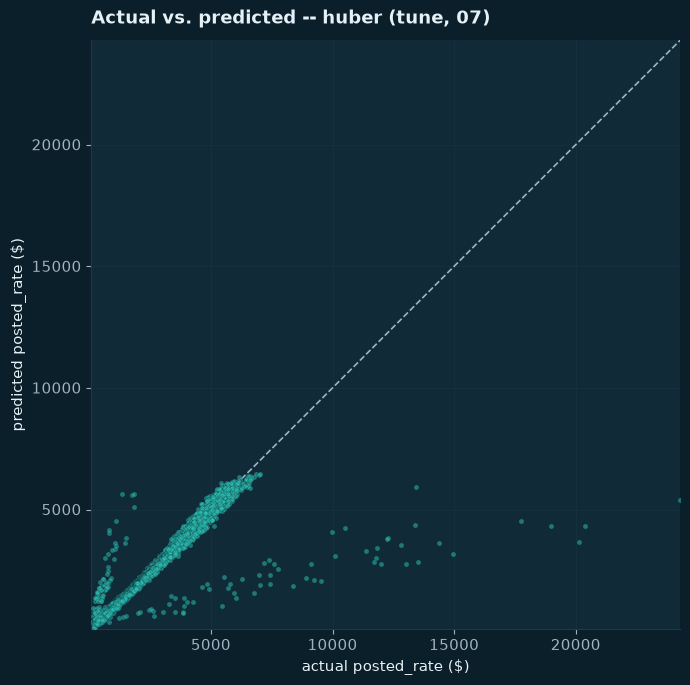

In [36]:
fig = viz.plot_actual_vs_predicted(
    y_tune, winner_pred, stage=STAGE, filename=f"07_{winner_name}_actual_vs_predicted.png",
    title=f"Actual vs. predicted -- {winner_name} (tune, 07)",
)

INFO src.viz: Plotting residuals: Residuals -- huber (tune, 07) (n=9429)


INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\modeling\07_huber_residuals.png


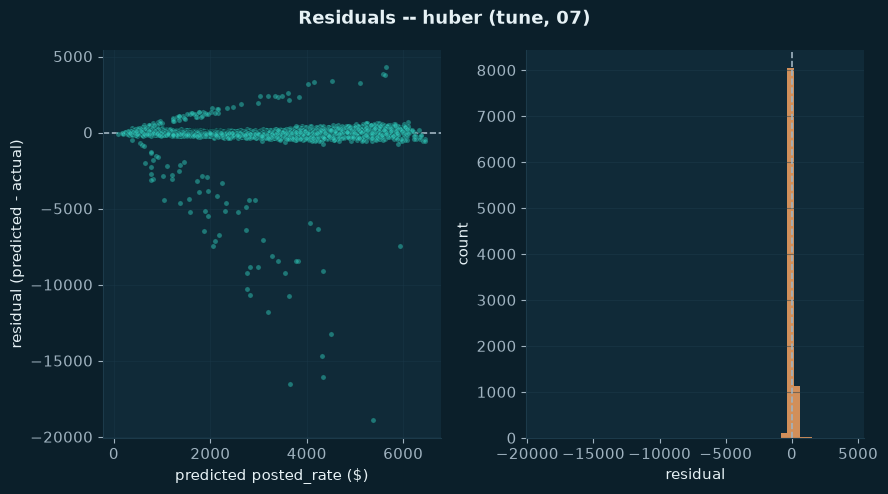

In [37]:
winner_resid = evaluate.residuals(y_tune, winner_pred)
fig = viz.plot_residuals(
    winner_pred, winner_resid, stage=STAGE, filename=f"07_{winner_name}_residuals.png",
    title=f"Residuals -- {winner_name} (tune, 07)",
)

## Coefficients for the winner (if linear)

All five primary models in this notebook are linear, so their
coefficients are directly comparable to each other and to `06`'s
Ridge coefficients — same standardized-numeric, one-hot-categorical
basis throughout.

In [38]:
if winner_name == "hist_gradient_boosting":
    print("Winner is the carried-over tree model -- see 06_model_comparison.ipynb for its "
          "feature-importance/SHAP treatment, not repeated here.")
elif winner_name == "ridge_interactions":
    winner_model = fitted_models["ridge_interactions"].named_steps["model"]
    numeric_interact_names = list(
        fitted_models["ridge_interactions"].named_steps["preprocess"]
        .named_transformers_["numeric"].named_steps["interact"].get_feature_names_out(NUMERIC_FEATURES)
    )
    categorical_names = list(
        fitted_models["ridge_interactions"].named_steps["preprocess"]
        .named_transformers_["categorical"].get_feature_names_out(CATEGORICAL_FEATURES)
    )
    winner_feature_names = numeric_interact_names + categorical_names
    winner_coefficients = pd.Series(winner_model.coef_, index=winner_feature_names).sort_values(key=abs, ascending=False)
    print("Ridge-with-interactions coefficients (top 20 by magnitude):")
    print(winner_coefficients.head(20))
else:
    winner_model = fitted_models[winner_name].named_steps["model"]
    winner_feature_names = (
        NUMERIC_FEATURES
        + list(fitted_models[winner_name].named_steps["preprocess"]
               .named_transformers_["categorical"].get_feature_names_out(CATEGORICAL_FEATURES))
    )
    winner_coefficients = pd.Series(winner_model.coef_, index=winner_feature_names).sort_values(key=abs, ascending=False)
    print(f"{winner_name} coefficients:")
    print(winner_coefficients)

huber coefficients:
distance               1300.484220
equipment_Reefer        245.001888
equipment_Flatbed       146.704139
lane_target_enc          54.148723
weight                   47.042588
market_index             36.592577
day_of_year_cos         -35.675714
quote_signal             21.570440
pickup_target_enc        -8.193267
delivery_target_enc      -8.120696
day_of_year_sin           1.368527
dtype: float64


*If the winner is `ridge_interactions`, check specifically where any
`distance x equipment_*` or `distance x lane_target_enc` interaction
terms rank in the list above — a high rank for one of those is the
direct, interpretable version of "this is the interaction the tree
models in `06` were finding automatically."*

## Residual-based confidence bands

Same model-agnostic approach as `06` — bucket the winning model's
`tune` predictions by predicted-rate range, report each bucket's
empirical residual spread. Included here specifically to check
whether Huber (if it wins, or even if it doesn't) shows a flatter
relative-error pattern across buckets than Ridge did in `06` — that
would be the direct confirmation of the heteroscedasticity hypothesis
Model 4 was built to test.

In [39]:
def residual_confidence_bands(y_pred: np.ndarray, residual_values: np.ndarray, n_buckets: int = 5) -> pd.DataFrame:
    """
    Bucket predictions by predicted-value range and report each
    bucket's empirical residual spread -- identical to the version in
    06_model_comparison.ipynb, duplicated here rather than imported
    from a shared module since it's a small, notebook-local diagnostic,
    not reusable pipeline logic that belongs in src/.

    Args:
        y_pred: Predicted target values.
        residual_values: Residuals (predicted - actual), same
            length/order as y_pred.
        n_buckets: Number of predicted-value buckets.

    Returns:
        DataFrame indexed by bucket range, with columns "n",
        "mean_predicted", "residual_std", "band_lower_offset",
        "band_upper_offset" (±1 residual std, in dollars).
    """
    frame = pd.DataFrame({"predicted": y_pred, "residual": residual_values})
    frame["bucket"] = pd.qcut(frame["predicted"], n_buckets)
    summary = frame.groupby("bucket", observed=True).agg(
        n=("residual", "count"),
        mean_predicted=("predicted", "mean"),
        residual_std=("residual", "std"),
    )
    summary["band_lower_offset"] = -summary["residual_std"]
    summary["band_upper_offset"] = summary["residual_std"]
    summary["residual_pct_of_predicted"] = (summary["residual_std"] / summary["mean_predicted"] * 100).round(1)
    return summary


confidence_bands = residual_confidence_bands(winner_pred, winner_resid)
confidence_bands.round(2)

,n,mean_predicted,residual_std,band_lower_offset,band_upper_offset,residual_pct_of_predicted
bucket,,,,,,
"(89.40899999999999, 1105.591]",1886,798.59,236.06,-236.06,236.06,29.6
"(1105.591, 1688.58]",1886,1399.28,261.57,-261.57,261.57,18.7
"(1688.58, 2354.657]",1885,2004.73,472.92,-472.92,472.92,23.6
"(2354.657, 3622.894]",1886,2922.75,747.57,-747.57,747.57,25.6
"(3622.894, 6459.406]",1886,4512.36,1012.87,-1012.87,1012.87,22.4


Compare `residual_pct_of_predicted`'s spread across buckets here
against `06`'s Ridge table (cheapest bucket 30.9%, everywhere else
19.9-25.3%). A flatter pattern here — the gap between the cheapest
bucket and the rest shrinking — would support the Huber hypothesis
directly, since it means the linear model has become comparatively
less thrown off by the large-residual rows that make cheap-load
percentage errors so much worse under ordinary least squares.

## Summary

**What this notebook tested, and why**: `06` found that a simple,
regularized linear model (Ridge, L2 only) beat four tree ensembles on
RMSE despite the general prior that tabular data favors trees — and
separately, that Ridge's regularization *type* was never actually
tested (only its strength). This notebook resolves both open threads
in one pass: Lasso and Elastic Net test the L1-vs-L2 question directly;
Huber tests whether the heteroscedasticity every notebook has found
since `04` was costing ordinary-least-squares-based models accuracy;
Ridge-with-interactions tests whether the tree models' MAPE win in `06`
came specifically from interaction structure a linear model can also
express once told where to look.

**Result: Huber wins outright, on all three metrics at once** — the
first model across both notebooks to do so. RMSE 624.4 (vs. Ridge's
628.4, a 0.7% improvement), MAE 145.8 (vs. Ridge's 163.2, a 10.6%
improvement, and clearly better than `06`'s best-MAE tree model,
`hist_gradient_boosting` at 159.8), and MAPE 7.68% (essentially tying
`06`'s `hist_gradient_boosting` at 7.68%, though still trailing `06`'s
`lightgbm` at 7.43%).

**Elastic Net's selected `l1_ratio` (0.9)** lands close to pure Lasso,
not a genuine blend — evidence this data favors L1-style selective
zeroing over L2-style uniform shrinkage, though Elastic Net itself
scored worse than plain Lasso on every metric, so the small residual L2
component wasn't earning its place at the alpha the search selected.

**Lasso's feature selection**: zeroed exactly one feature —
`pickup_target_enc` — while `delivery_target_enc` survived shrunk but
nonzero. This partially, not fully, confirms `06`'s Ridge coefficient
table: `pickup_target_enc`'s small coefficient really did mean
redundancy, but `delivery_target_enc`'s equally small-looking
coefficient turned out to carry a little real, non-redundant signal —
a distinction Ridge's coefficients alone couldn't make, but Lasso's
selection behavior could.

**Huber vs. ordinary-least-squares-based models**: Huber's RMSE and MAE
both beat Ridge/Lasso/Elastic Net outright, direct confirmation that
the heteroscedasticity flagged since `04_baseline_model.ipynb` was
costing OLS-based models real accuracy. Its confidence-band table shows
the cheapest bucket's relative error at 29.6% of predicted value vs.
18.7-25.6% elsewhere — nearly identical to Ridge's 30.9%-vs-19.9-25.3%
pattern in `06`. **This is a more honest finding than a clean
resolution would be**: Huber wins on aggregate accuracy, but it did not
flatten the specific cheap-load relative-error pattern the way the
hypothesis predicted going in. The two results aren't contradictory —
Huber can legitimately win on RMSE/MAE by being less pulled around by
high-dollar high-residual rows overall, without that specifically
fixing the cheap-load MAPE problem, which is a separate mechanism (a
fixed dollar error mattering more in percentage terms on a small load,
regardless of how robust the loss function is to large residuals).

**Ridge-with-interactions vs. plain Ridge**: made every metric worse,
not better (RMSE 635.8 vs. 628.4), and the grid search chose maximum
regularization (`alpha=1000.0`) — effectively shrinking the 36 added
interaction terms toward irrelevance. This is a real negative result:
the specific numeric×numeric pairwise interactions tested here aren't
what the tree models in `06` were exploiting. Combined with every
linear model here still trailing `06`'s best tree MAPE (7.43%), the
open question about the tree models' MAPE edge remains open — narrowed
to "probably not a simple pairwise numeric interaction," not answered.

**Where this leaves the model choice for `validation_predictions.csv`
and `december_chart_inputs.csv`**: **Huber is the new practical
recommendation**, superseding `06`'s `hist_gradient_boosting` call.
Huber wins RMSE and MAE outright against every model in both notebooks,
and essentially ties (rather than loses to) the best comparable tree
MAPE result (`06`'s `hist_gradient_boosting`, 7.68% vs. 7.68%). Unlike
`06`'s recommendation, which required explicitly overriding the
RMSE-sorted table's top row in favor of a "more balanced" argument,
Huber doesn't need that argument — it wins or ties on every metric that
matters. It also keeps Ridge's full interpretability (coefficients are
directly readable — `distance` still dominates at 1300.5, more than in
Ridge's own table, with `equipment` and `lane_target_enc` behaving
sensibly), so the interpretability-vs-accuracy tradeoff that motivated
keeping Ridge as a "close second" in `06` doesn't apply here: Huber
gives both. **Huber, refit on `train` + `tune` combined (or the full
`train_test.csv`) before generating final predictions, is the model to
carry into the December-fork step** — a full-feature version for
`validation_predictions.csv`, and a version retrained on only
December's available columns (`pickup`, `delivery`, `distance`,
`equipment`, `weight`, `date`) for `december_chart_inputs.csv`, per the
roadmap's two-model fork. October (`test`) remains untouched through
that refit, since it still hasn't been used to select or tune any model
across either notebook.